In [ ]:
# Clone repo (if running in Colab)
!git clone https://github.com/Gnpd/Chemometric-approaches-to-hyperspectral-processing.git

# Navigate into the cloned repository
%cd Chemometric-approaches-to-hyperspectral-processing

# Install dependencies
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
  Using cached segment_anything-1.0-py3-none-any.whl


In [11]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import os
# Define the path to your data and result folders in Google Drive
# data_path="data"
# results_dir = "results"
data_path = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing/data'
results_dir = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing_Results'
os.makedirs(results_dir, exist_ok=True)

# Spectral analysis

This notebook demonstrates a complete workflow for spectral analysis and calibration modeling.

It covers:
1. Loading and visualizing spectral and reference data.
2. Unsupervised outlier detection using PCA and Mahalanobis distance.
3. Outlier removal based on input and output variables.
4. Preprocessing techniques: smoothing, scatter correction (MSC/SNV), and derivatives. Using the `chemotools` library.
5. Automated preprocessing pipeline search using `sklearn.GridSearchCV` + `Pipeline` (replaces nippy; fixes data leakage in CV).
6. Data partitioning methods: Kennard-Stone, DUPLEX, and SPXY. Using the `contributions` module.
7. Calibration modeling: Principal Component Regression (PCR) and Partial Least Squares Regression (PLSR).
8. Model diagnostics and supervised outlier detection using `chemotools.outliers` (HotellingT2, QResiduals).
9. Deep learning regression using fully connected neural networks.

## Loading of the spectral data and references

As a first step we will load the average spectra of kiwi that we generated in the previous lab. We also load reference values (dry matter and soluble solids content) and select the refernce values that correspond to extracted spectra.

In [28]:
import numpy as np

kiwi_spectra = np.loadtxt(f"{results_dir}/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt(f"{data_path}/reference.csv", delimiter=",")
wl = np.loadtxt(f"{results_dir}/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, :] # Select correct refernce values (first 180 rows) that exclude golden kiwi sort
reference_values.shape

(180, 2)

## Outliers removal (unsupervised, PCA)

Due to potential mishaps in our measurements or extraction of spectra per kiwi and various other reasons we may end up having outliers in our dataset. These outliers can cause problems when training chemometrics/machine learning model. Let's explore unsupervised outlier removal that we perform using principal component analysis (PCA):

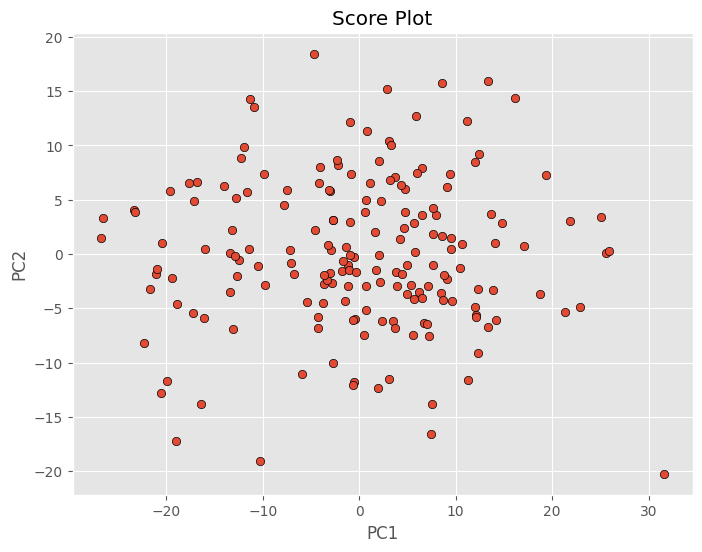

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

scaler = StandardScaler()
scaled_data = scaler.fit_transform(kiwi_spectra)
 
pca = PCA(random_state=42)
 
# Run PCA on scaled data (since PCA is sensitive to feature scale) and obtain the scores array
T = pca.fit_transform(scaled_data)
 
# Score plot of the first 2 PC
fig = plt.figure(figsize=(8,6))
with plt.style.context(('ggplot')):
    plt.scatter(T[:, 0], T[:, 1], edgecolors='k')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Score Plot')
plt.show()

Let's plot explained variance by each principal component

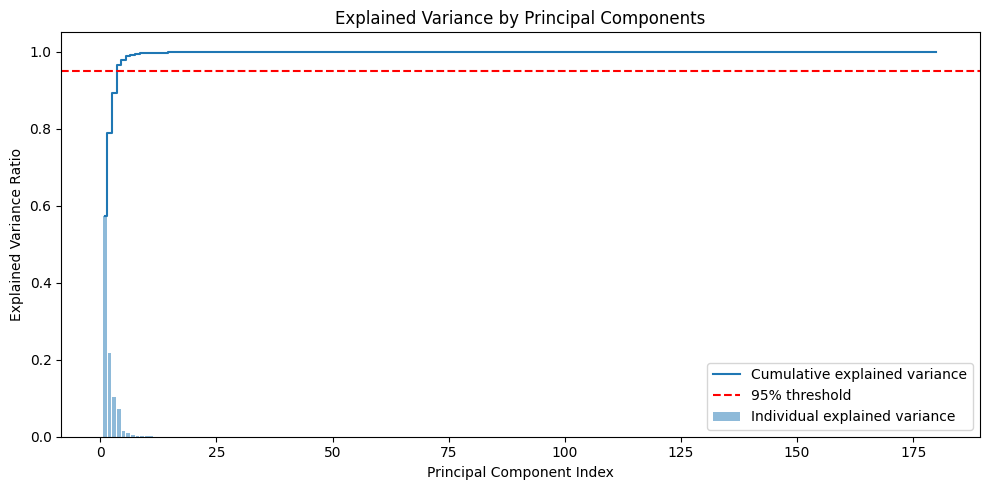

Number of components explaining 95% variance: 4


In [30]:
explained_var_ratio = pca.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_var_ratio)+1), explained_var_ratio, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_var_ratio)+1), cumulative_var_ratio, where='mid', label='Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_var_ratio >= 0.95) + 1
print(f"Number of components explaining 95% variance: {n_components_95}")

We can check how the first components that explain 95% variance can reconstruct the spectra.

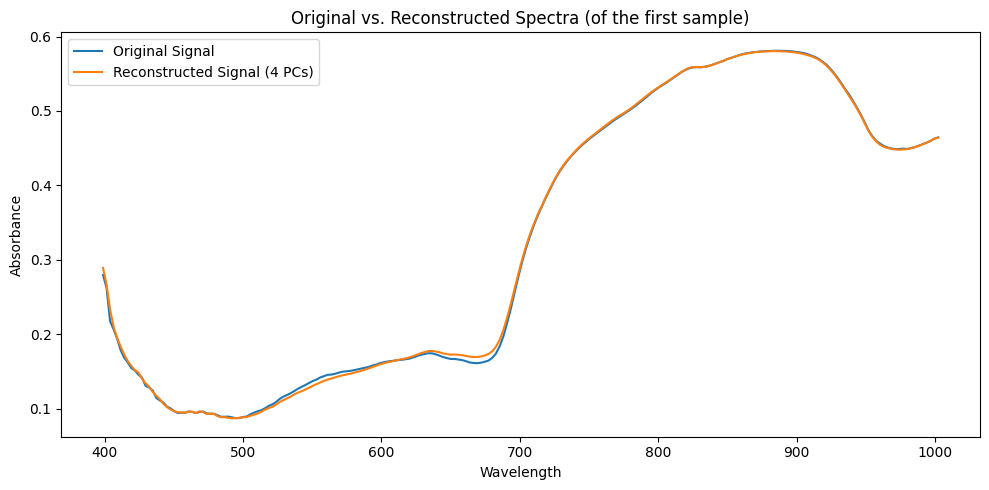

In [31]:
pca_95 = PCA(n_components=n_components_95, random_state=42)
T_95 = pca_95.fit_transform(scaled_data)
reconstructed = pca_95.inverse_transform(T_95)
reconstructed_original_scale = scaler.inverse_transform(reconstructed)

sample_idx = 0  # You can change this index to look at other samples
plt.figure(figsize=(10, 5))
plt.plot(wl, kiwi_spectra[sample_idx], label='Original Signal')
plt.plot(wl, reconstructed_original_scale[sample_idx], label=f'Reconstructed Signal ({n_components_95} PCs)')
plt.title('Original vs. Reconstructed Spectra (of the first sample)')
plt.xlabel('Wavelength')
plt.ylabel('Absorbance')
plt.legend()
plt.tight_layout()
plt.show()

It's a hard task to analyze every spectra across all wavelengths. By computing principal components we can identify where most of variance in our data is and focus on a few first components. After simplifying our data to first let's say 4 components, we can detect outliers by computing distance of each point to the rest. The straightforward way is to compute Euclidean distance, but:
  - It assumes variables are uncorrelated, which can be misleading when there's correlation between axes (e.g. tilted ellipsoids in PCA score plots).
  - Redundant or correlated variables can distort distance measures, unintentionally amplifying their influence.
  - It is sensitive to outliers, which skew mean and standard deviation—making it hard to identify those same outliers.

**Solution: Mahalanobis Distance**
  - Accounts for the **covariance structure** of the data, giving less weight to directions with high variance (i.e., redundancy).
  - Can be calculated robustly using **Minimum Covariance Determinant (MCD)** from `sklearn.covariance`.
  - When applied to PCA-transformed data, it highlights observations that deviate from the multivariate distribution.

In [32]:
# --- Manual implementation (what's happening inside) ---
# MinCovDet fits a robust covariance estimator (resistant to outliers corrupting
# the covariance estimate) then measures how far each sample sits from the centre.
# from sklearn.covariance import MinCovDet
# robust_cov = MinCovDet(random_state=42).fit(T[:, :n_components_95])
# mahalanobis = robust_cov.mahalanobis(T[:, :n_components_95])

# --- With chemotools ---
# HotellingT2 computes T² = Σ_j (t_ij / s_j)²: the variance-weighted squared
# distance of each sample from the model centre in PCA score space.
# When PCA components are uncorrelated (by construction), this is exactly the
# Mahalanobis distance in latent space — no need for a separate covariance estimator.
from chemotools.outliers import HotellingT2

hotelling = HotellingT2(model=pca_95, confidence=0.99)
hotelling.fit(scaled_data)
mahalanobis = hotelling.predict_residuals(scaled_data)  # T² value per sample

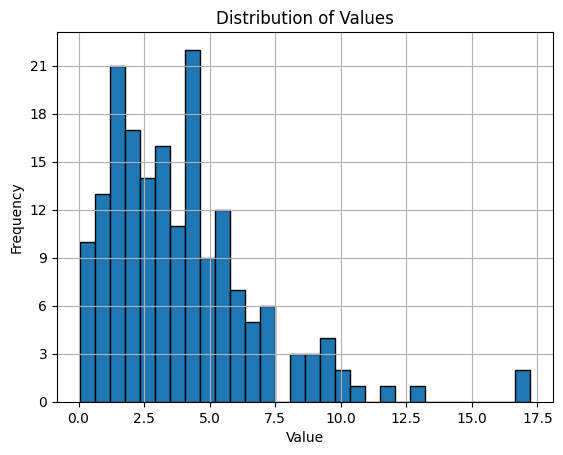

In [33]:
# Plot histogram
plt.hist(mahalanobis, bins=30, edgecolor='black') 
plt.title("Distribution of Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.gca().yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
plt.grid(True)
plt.show()

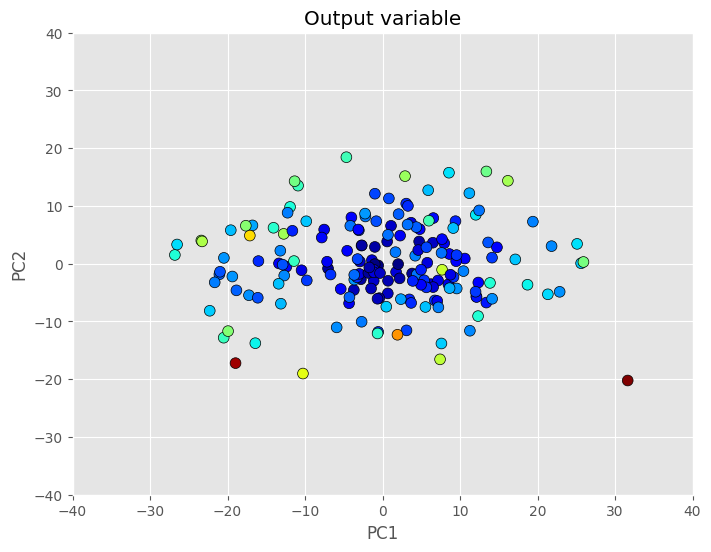

In [34]:
colors = [plt.cm.jet(float(i)/max(mahalanobis)) for i in mahalanobis]
fig = plt.figure(figsize=(8,6))
with plt.style.context(('ggplot')):
    plt.scatter(T[:, 0], T[:, 1], c=colors, edgecolors='k', s=60)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.xlim((-40, 40))
    plt.ylim((-40, 40))
    plt.title('Output variable')
plt.show()

Here we can see that there are a few outliers (in reddish and yellow colours). We now apply a statistical threshold to flag them formally.

The classical approach sets a **chi-square threshold** on the Mahalanobis distance: under multivariate normality, $T^2 \sim \chi^2(k)$ where $k$ is the number of PCA components. This is an approximation, it becomes increasingly optimistic for small sample sizes because it ignores the uncertainty in estimating the covariance from a finite dataset.

**`chemotools.outliers.HotellingT2`** uses the exact **F-distribution** critical value instead:

$$F\!\left(k,\; n - k\right) \quad \text{with } n = \text{number of samples}$$

This is the standard threshold in chemometrics software (e.g. SIMCA) and is strictly more accurate than the chi-square approximation for the sample sizes typical in spectroscopy. The detector also follows the sklearn anomaly detection convention: `predict()` returns `−1` for outliers and `+1` for inliers.

In [35]:
# --- Manual implementation (what's happening inside) ---
# Under multivariate normality T² ~ chi²(df=n_components_95).
# This ignores sampling uncertainty in the covariance estimate and
# becomes too permissive (misses outliers) for small datasets.
# from scipy.stats import chi2
# threshold = chi2.ppf(0.99, df=n_components_95)
# outliers = mahalanobis > threshold
# outlier_indices_input = np.where(outliers)[0]

# --- With chemotools ---
# HotellingT2.predict() derives the threshold from the F-distribution:
#   F(n_components_95, n_samples − n_components_95)
# This is the textbook-correct small-sample critical value used in SIMCA and
# most chemometrics software. Returns −1 for outliers, +1 for inliers.
outliers = hotelling.predict(scaled_data) == -1
outlier_indices_input = np.where(outliers)[0]

print("Outlier indices:", outlier_indices_input)

Outlier indices: [45 75]


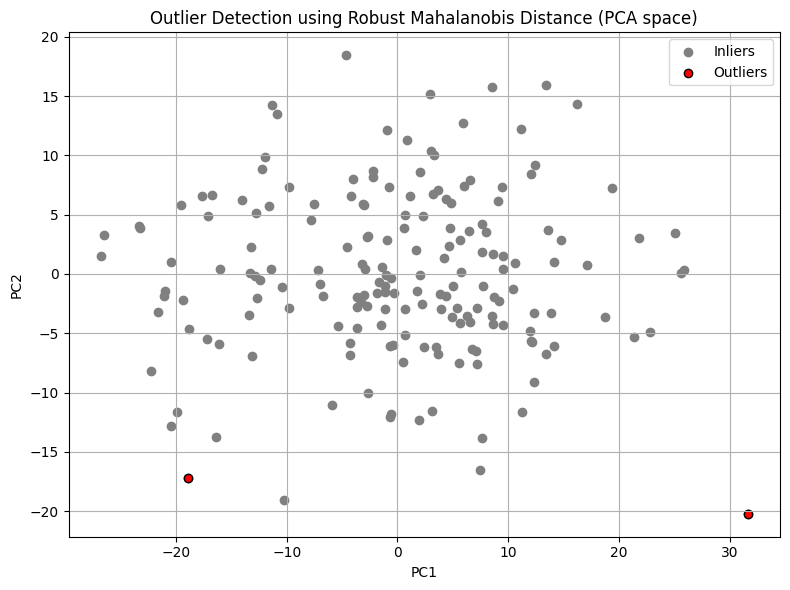

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(T[:, 0], T[:, 1], c='gray', label='Inliers')
plt.scatter(T[outliers, 0], T[outliers, 1], c='red', label='Outliers', edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Outlier Detection using Robust Mahalanobis Distance (PCA space)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Outlier removal from multiple references

Let's repeat the same exercise for our output variables. Since we only have two target variables it does not make sense to compute PCA, since it's a dimension-reduction technique. Let's compute mahalanobis distance based on robust covariance matrix of the output variables.

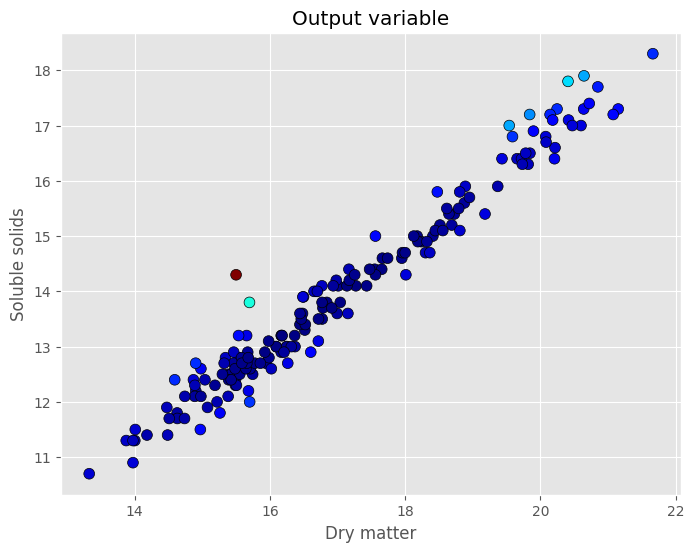

In [37]:
# Unlike the X-space case (cell above), there is no underlying PCA/PLS model here —
# we are working directly in the 2D reference space (dry matter × soluble solids).
# chemotools.HotellingT2 requires a fitted model, so we keep MinCovDet + Mahalanobis,
# which is the standard and more appropriate approach for raw multivariate output data.
# MinCovDet (Minimum Covariance Determinant) is a robust estimator: it fits the
# covariance matrix on the subset of samples least likely to contain outliers,
# so outliers do not distort the very measure used to detect them.
robust_cov = MinCovDet(random_state=42).fit(reference_values)
mahalanobis = robust_cov.mahalanobis(reference_values)

colors = [plt.cm.jet(float(i)/max(mahalanobis)) for i in mahalanobis]
fig = plt.figure(figsize=(8,6))
with plt.style.context(('ggplot')):
    plt.scatter(reference_values[:, 0], reference_values[:, 1], c=colors, edgecolors='k', s=60)
    plt.xlabel('Dry matter')
    plt.ylabel('Soluble solids')
    plt.title('Output variable')
plt.show()

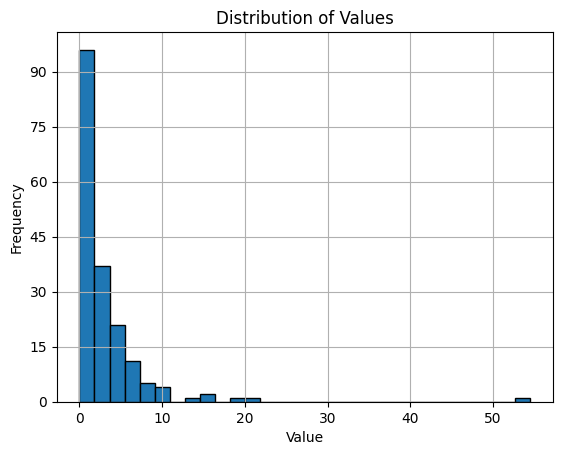

In [38]:
# Plot histogram
plt.hist(mahalanobis, bins=30, edgecolor='black')  
plt.title("Distribution of Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.gca().yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
plt.grid(True)
plt.show()

In [39]:
# --- Manual implementation (what's happening inside) ---
# Chi-square threshold: T² ~ χ²(df=p) holds only asymptotically (large n).
# For finite n this is too permissive — it sets the boundary too far out,
# causing genuine outliers to fall inside.
# from scipy.stats import chi2
# threshold = chi2.ppf(0.99, df=2)

# --- F-distribution correction (same formula HotellingT2 uses internally) ---
# For n samples and p variables the exact small-sample critical value is:
#   T²_crit = p(n−1)/(n−p) × F_{p, n−p, α}
# chemotools.HotellingT2 derives its threshold this way when wrapping a PCA/PLS
# model. Here, with no such model, we apply the formula directly.
from scipy.stats import f as f_dist

n, p = len(reference_values), 2
threshold = p * (n - 1) / (n - p) * f_dist.ppf(0.99, dfn=p, dfd=n - p)

outliers = mahalanobis > threshold
outlier_indices_output = np.where(outliers)[0]

print("Outlier indices (based on output variables):", outlier_indices_output)

Outlier indices (based on output variables): [ 35  77 100 150 154 155 159]


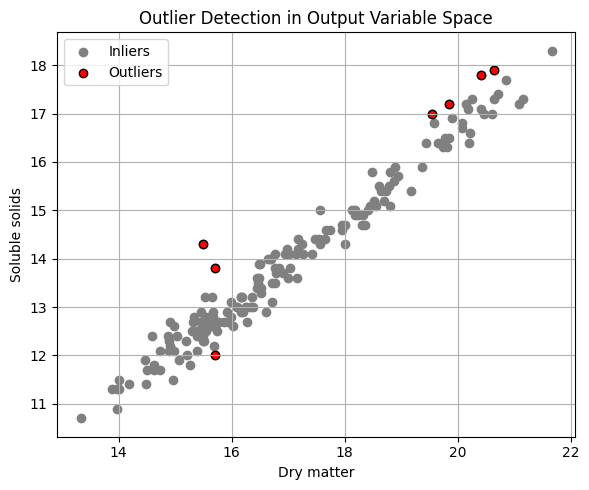

In [40]:
plt.figure(figsize=(6, 5))
plt.scatter(reference_values[:, 0], reference_values[:, 1], c='gray', label='Inliers')
plt.scatter(reference_values[outliers, 0], reference_values[outliers, 1], c='red', edgecolors='k', label='Outliers')
plt.xlabel('Dry matter')
plt.ylabel('Soluble solids')
plt.title('Outlier Detection in Output Variable Space')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Outlier removal from single reference value

Using the mean ± 3 standard deviations (3σ rule) is a common and simple method based on the assumption that the data is approximately normally distributed. In a normal distribution about 99.7% of the data falls within ±3 standard deviations from the mean.

Values beyond this range are considered statistically rare and often indicative of outliers.

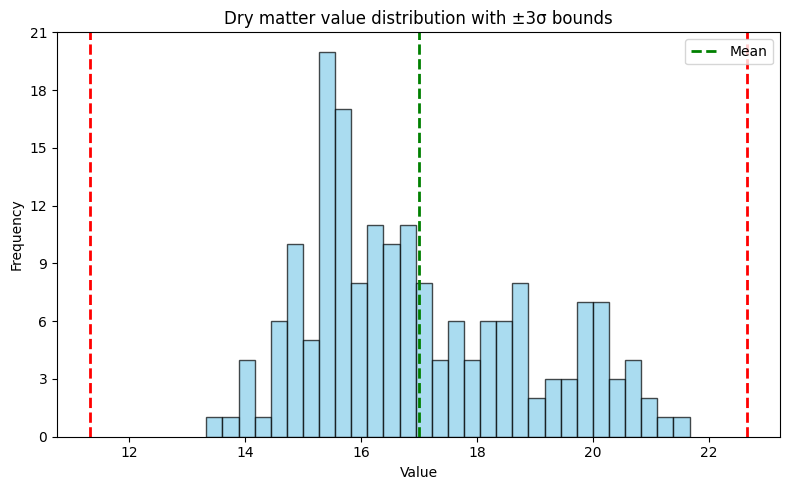

Outlier indices: []


In [41]:
# Let's say we choose Dry Matter as our target output variable
reference = reference_values[:,0]

# Compute mean and standard deviation
mean = np.mean(reference)
std = np.std(reference)

# Define bounds
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

plt.figure(figsize=(8, 5))
plt.hist(reference, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(mean, color='green', linestyle='--', linewidth=2, label='Mean')
plt.axvline(lower_bound, color='red', linestyle='--', linewidth=2)
plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2)
plt.title('Dry matter value distribution with ±3σ bounds')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.gca().yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


outlier_indices_single_reference = np.where((reference < lower_bound) | (reference > upper_bound))[0]
print("Outlier indices:", outlier_indices_single_reference)

In [42]:
# Combine unique outlier indices from both sources
combined_outliers = np.union1d(outlier_indices_input, outlier_indices_output)

# Remove those rows from input and output data
X_clean = np.delete(kiwi_spectra, combined_outliers, axis=0)
Y_clean = np.delete(reference, combined_outliers, axis=0)

print(f"Removed {len(combined_outliers)} outliers. Cleaned data shape:")
print("X_clean:", X_clean.shape)
print("Y_clean:", Y_clean.shape)

Removed 9 outliers. Cleaned data shape:
X_clean: (171, 224)
Y_clean: (171,)


## Pre-processing of data

### Smoothing

Smoothing is applied to reduce noisiness of spectra. The Savitzky–Golay filter is a commonly used smoothing method that fits a low-degree polynomial to a sliding window of data points using least squares. It preserves important features like peak shape and height better than moving average filters.

**Parameters**:
- `window_length`: number of points in the smoothing window (must be odd)
- `polyorder`: degree of the fitted polynomial

In [44]:
X_example = X_clean[0, :]
w, p = 13, 2

# --- Manual implementation (what's happening inside) ---
# from scipy.signal import savgol_filter
# X_smooth_1 = savgol_filter(X_example, w, polyorder=p, deriv=0)

# --- With chemotools ---
from chemotools.smooth import SavitzkyGolayFilter

smoother = SavitzkyGolayFilter(window_length=w, polyorder=p)
X_smooth_1 = smoother.fit_transform(X_example.reshape(1, -1)).ravel()

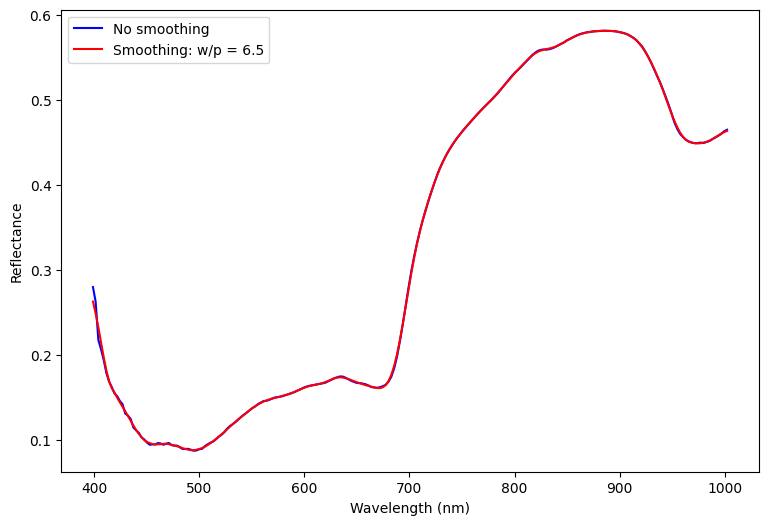

In [45]:
plt.figure(figsize=(9,6))
interval = np.arange(0,224,1)
plt.plot(wl[interval], X_example[interval], 'b', label = 'No smoothing')
plt.plot(wl[interval], X_smooth_1[interval], 'r', label = f'Smoothing: w/p = {w/p}')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.legend()
plt.show()

## Scatter correction

Two common methods to reduce light-scattering effects in spectra:

1. **Multiplicative Scatter Correction (MSC)**
- Corrects each spectrum by *regressing* against a reference spectrum, often the dataset mean.
- Removes both additive (baseline offset) and multiplicative (slope) distortions.  
- Reference spectrum must be chosen or estimated.  

2. **Standard Normal Variate (SNV)**
- Normalizes each spectrum individually without needing a reference.  
- Centers to zero mean and scales to unit variance.  
- Simple and effective for both additive and multiplicative scatter.

---

- Use **MSC** if a reliable reference spectrum is available (e.g., repeated blank or ideal sample).
- Use **SNV** when reference isn't available or to preprocess each sample individually.
- Both help improve calibration models by removing unwanted variability due to sample morphology or measurement conditions.

In [46]:
# --- Manual implementation (what's happening inside) ---
# def snv(input_data):
#     output_data = np.zeros_like(input_data)
#     for i in range(input_data.shape[0]):
#         output_data[i, :] = (input_data[i, :] - np.mean(input_data[i, :])) / np.std(input_data[i, :])
#     return output_data

# --- With chemotools ---
from chemotools.scatter import StandardNormalVariate

snv = StandardNormalVariate()

In [47]:
# --- Manual implementation (what's happening inside) ---
# def msc(input_data, reference=None):
#     for i in range(input_data.shape[0]):
#         input_data[i, :] -= input_data[i, :].mean()
#     ref = np.mean(input_data, axis=0) if reference is None else reference
#     data_msc = np.zeros_like(input_data)
#     for i in range(input_data.shape[0]):
#         fit = np.polyfit(ref, input_data[i, :], 1, full=True)
#         data_msc[i, :] = (input_data[i, :] - fit[0][1]) / fit[0][0]
#     return data_msc, ref

# --- With chemotools ---
from chemotools.scatter import MultiplicativeScatterCorrection

msc = MultiplicativeScatterCorrection()  # uses mean spectrum as reference by default

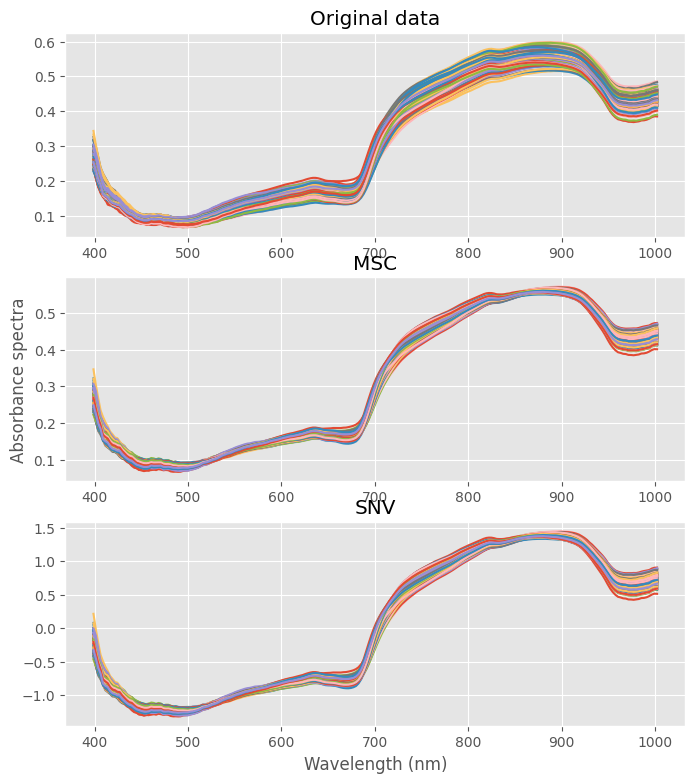

In [48]:
import matplotlib.pyplot as plt

# snv and msc are now chemotools transformers — they follow sklearn's fit/transform API.
# fit() learns the reference (MSC: mean spectrum; SNV: no fitting needed, it's per-sample).
# transform() applies the correction to any new data using the fitted reference.

Xmsc = msc.fit_transform(X_clean.copy())
Xsnv = snv.fit_transform(X_clean.copy())

## Plot spectra
plt.figure(figsize=(8, 9))
with plt.style.context(('ggplot')):
    ax1 = plt.subplot(311)
    plt.plot(wl, X_clean.T)
    plt.title('Original data')

    ax2 = plt.subplot(312)
    plt.plot(wl, Xmsc.T)
    plt.ylabel('Absorbance spectra')
    plt.title('MSC')

    ax3 = plt.subplot(313)
    plt.plot(wl, Xsnv.T)
    plt.xlabel('Wavelength (nm)')
    plt.title('SNV')
    plt.show()

## Derivative

Derivatives of spectra help enhance features like peaks and reduce baseline effects. The **Savitzky–Golay filter** fits a local polynomial to each spectrum and computes its derivatives analytically.

- **First derivative**: highlights slopes and inflection points (e.g. rate of change)
- **Second derivative**: emphasizes peak curvature and separates overlapping peaks

This is useful for improving model performance in spectroscopy, especially when baseline shift or scatter affects raw spectra.

We apply Savitzky–Golay using `scipy.signal.savgol_filter`.

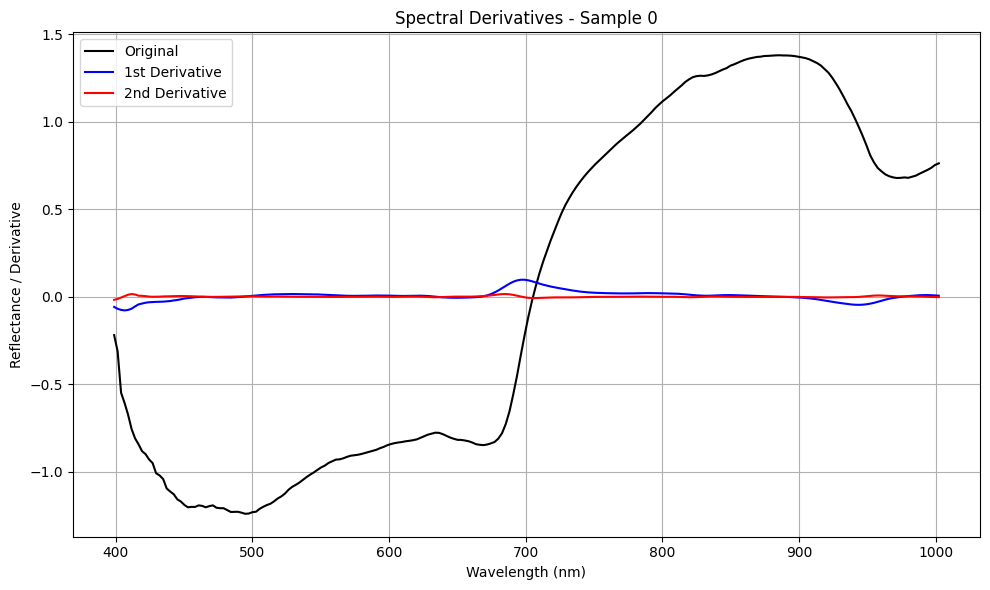

In [49]:
# --- Manual implementation (what's happening inside) ---
# from scipy.signal import savgol_filter
# X_cal_1st = savgol_filter(Xsnv, window_length=11, polyorder=2, deriv=1, axis=1)
# X_cal_2nd = savgol_filter(Xsnv, window_length=11, polyorder=2, deriv=2, axis=1)

# --- With chemotools ---
from chemotools.derivative import SavitzkyGolay

sg_1st = SavitzkyGolay(window_length=11, polyorder=2, deriv=1)
sg_2nd = SavitzkyGolay(window_length=11, polyorder=2, deriv=2)

X_cal_1st = sg_1st.fit_transform(Xsnv)
X_cal_2nd = sg_2nd.fit_transform(Xsnv)

sample_idx = 0
plt.figure(figsize=(10, 6))
plt.plot(wl, Xsnv[sample_idx], label='Original', color='black')
plt.plot(wl, X_cal_1st[sample_idx], label='1st Derivative', color='blue')
plt.plot(wl, X_cal_2nd[sample_idx], label='2nd Derivative', color='red')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance / Derivative")
plt.title(f"Spectral Derivatives - Sample {sample_idx}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Data partition

When training a calibration model it's very important to split our dataset to properly evaluate performance. There are various ways of doing so that are often applied to hyperspectral data (apart from random split via `train_test_split`).

### Kennard-Stone partition

The Kennard–Stone (KS) algorithm is a deterministic method for selecting a representative calibration set from a dataset. It ensures that selected samples are evenly spread across the input (X) space.

How it works:
1. Compute pairwise distances between all samples in X.
2. Select the two samples that are farthest apart.
3. Iteratively add the sample that is most distant from the already selected set.
4. Continue until the desired number of samples is selected.

*Note:* KS uses only X (predictors) for selection — not Y (targets). For target-aware splitting, see SPXY algorithm below.

In [50]:
import kennard_stone as ks
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_validate

X_cal_ks, X_test_ks, y_cal_ks, y_test_ks = ks.train_test_split(X_clean, Y_clean, test_size = 0.2)

C:\Users\aguti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-04-30 13:33:28,103 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\aguti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-04-30 13:33:28,110 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

C:\Users\aguti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\deprecation.py:151:

In [51]:
def plot_split_cal_test(X_cal, X_test, y_cal, y_test):
    _, axs = plt.subplots(2,1,figsize=(8,10))
    _, bins, _ = axs[0].hist(y_cal, bins = 20, alpha=0.75, label="Calibration set")
    axs[0].hist(y_test, bins = bins, alpha=0.75, label="Test set")
    axs[0].legend()
    axs[0].set_xlabel("Dry matter content") 
    axs[0].set_ylabel("Number of samples")
    axs[0].yaxis.set_major_locator(mtick.MaxNLocator(integer=True))

    train_legend =  np.repeat("_Calibration", X_cal.shape[0])
    train_legend[0] = "Calibration set"
    test_legend =  np.repeat("_Test set", X_test.shape[0])
    test_legend[0] = "Test set"

    axs[1].plot(wl, X_cal.T, 'b', alpha=0.5, label = train_legend)
    axs[1].plot(wl, X_test.T, 'g', alpha=0.5, label = test_legend)
    axs[1].legend()
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("Kiwi spectra reflectance")
    plt.tight_layout()
    plt.show()

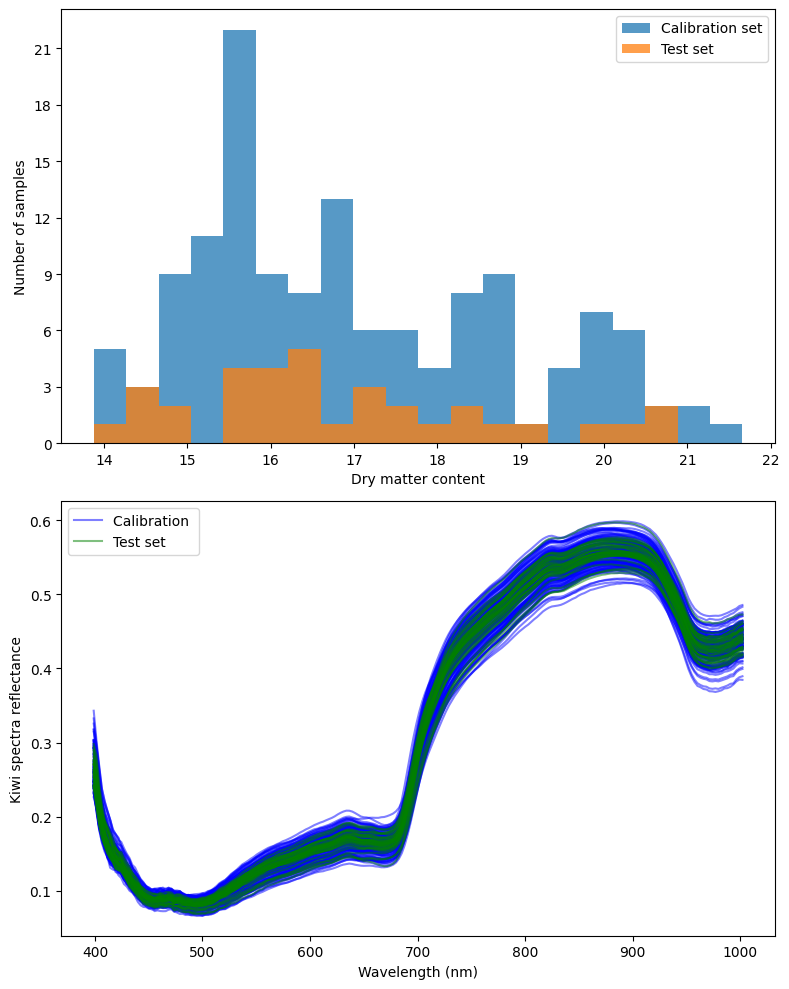

In [52]:
plot_split_cal_test(X_cal_ks, X_test_ks, y_cal_ks, y_test_ks)

### Duplex partition

The DUPLEX algorithm is a deterministic method for splitting a dataset into two representative sets (e.g., training and testing). It ensures both subsets cover the input space well — better than random splits, especially for small datasets.

How it works:
1. Compute pairwise distances between all samples.
2. Select the most distant pair → assign one to training, one to testing.
3. Alternately add the sample most distant from the current training/test set.
4. Repeat until all samples are assigned.

In [53]:
# --- Manual DUPLEX implementation replaced ---
# The original relied on torch.utils.data.TensorDataset (heavy dependency for a
# pure distance-based algorithm). The contributions module provides a clean,
# sklearn-compatible implementation.

from contributions.partitioning.spxy import duplex

In [54]:
cal_idx_duplex, test_idx_duplex = duplex(X_clean, test_size=0.2)

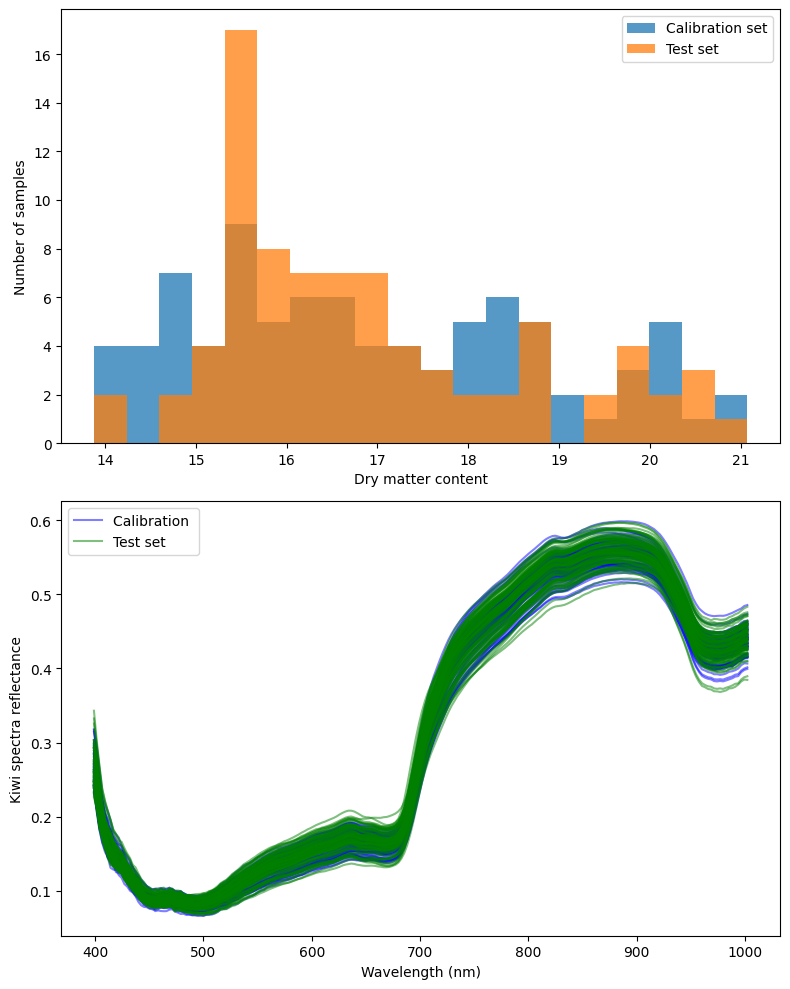

In [55]:
X_cal_duplex = X_clean[cal_idx_duplex]
X_test_duplex = X_clean[test_idx_duplex]
y_cal_duplex = Y_clean[cal_idx_duplex]
y_test_duplex = Y_clean[test_idx_duplex]

plot_split_cal_test(X_cal_duplex, X_test_duplex, y_cal_duplex, y_test_duplex)

### SPXY algorithm

SPXY is an enhanced variant of the Kennard–Stone (KS) method, designed for splitting datasets into calibration (train) and validation/test sets. While KS uses only the independent variables (X-space) to choose representative samples, SPXY uses both the predictors and the target variable (Y-space) to guide the selection.

In [56]:
# --- Manual SPXY implementation replaced ---
# The original was a 60-line inline implementation. The contributions module
# provides a clean, sklearn-compatible version.

from contributions.partitioning.spxy import spxy

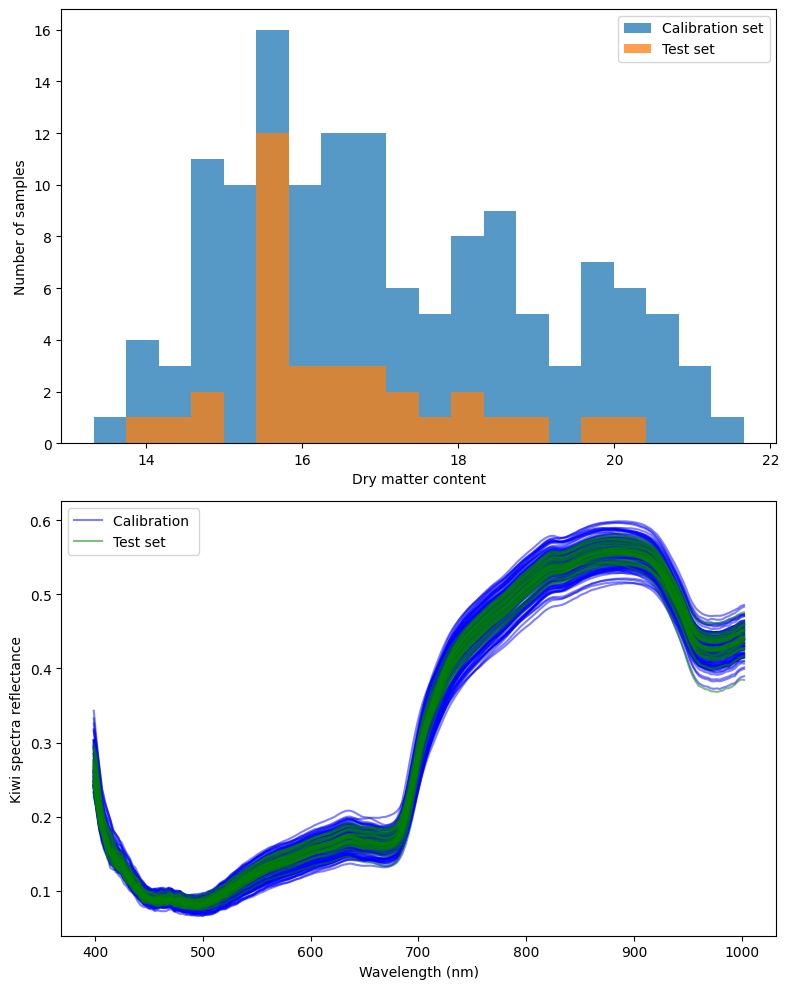

In [57]:
cal_indices, test_indices = spxy(X_clean, Y_clean, test_size=0.2)
X_cal_spxy, y_cal_spxy = X_clean[cal_indices], Y_clean[cal_indices]
X_test_spxy, y_test_spxy = X_clean[test_indices], Y_clean[test_indices]

plot_split_cal_test(X_cal_spxy, X_test_spxy, y_cal_spxy, y_test_spxy)

In [58]:
X_cal, y_cal, X_test, y_test = X_cal_spxy, y_cal_spxy, X_test_spxy, y_test_spxy # let's use SPXY split

## Automated preprocessing search with GridSearchCV

There are dozens of preprocessing combinations possible — different scatter corrections, derivative orders, smoothing windows. Rather than trying them by hand, we want to search over them automatically and pick the best one.

A previous version of this notebook used the `nippy` library for this. We replaced it with **`sklearn.GridSearchCV` + `Pipeline`** for two reasons:

**1. Data leakage.** `nippy` applies scatter correction (e.g. MSC) to the *full* calibration set before creating CV folds. MSC fits a reference (mean) spectrum on all samples — including the ones that will later act as validation. That reference therefore carries information from the validation fold into the model, making CV scores optimistically biased. With a sklearn `Pipeline`, every preprocessing step is fitted *inside* each CV fold, on training samples only. No leakage.

**2. Maintenance.** `nippy` is not on PyPI and has not been updated in years. `GridSearchCV` is core sklearn.

### How GridSearchCV works with a Pipeline

A `Pipeline` is a sequence of transformers followed by a final estimator. When passed to `GridSearchCV`:

- The grid defines the values each step (or step parameter) can take.
- Using `"passthrough"` as a step value means "skip this step" — this is how we search over which preprocessing steps to include.
- For each combination in the grid, `GridSearchCV` runs k-fold cross-validation: it **fits** the full pipeline (including all preprocessing) on the training folds and **evaluates** on the validation fold.
- The combination with the lowest mean CV error wins.
- `GridSearchCV` then refits the winning pipeline on the entire calibration set (`refit=True` by default), ready to use.

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from chemotools.scatter import MultiplicativeScatterCorrection, StandardNormalVariate
from chemotools.derivative import SavitzkyGolay
from chemotools.regression import PLSRegression as ChemoPLSRegression

# ── Step 1: Define the Pipeline skeleton ──────────────────────────────────────
# Each named step is a placeholder that the grid will fill in.
# Setting a step to "passthrough" at search time means "skip this step".
# The order matters: scatter correction → derivative/smoothing → SNV → model.
pipe = Pipeline([
    ("msc", "passthrough"),   # optional: Multiplicative Scatter Correction
    ("sg",  SavitzkyGolay()), # always applied: controls smoothing AND derivative order
    ("snv", "passthrough"),   # optional: Standard Normal Variate
    ("pls", ChemoPLSRegression()),
])

# ── Step 2: Define the search space ───────────────────────────────────────────
# Step values (msc, snv) toggle the step on/off.
# Step parameters (sg__deriv, sg__window_length, pls__n_components) tune the step.
# Naming convention: "<step_name>__<parameter_name>".
param_grid = {
    # Include MSC or skip it?
    "msc": [MultiplicativeScatterCorrection(), "passthrough"],

    # SavitzkyGolay with deriv=0 acts as a smoother only.
    # deriv=1 or 2 computes spectral derivatives (removes baseline, sharpens peaks).
    "sg__deriv":         [0, 1, 2],
    "sg__window_length": [5, 11, 13],   # must be odd and > polyorder

    # Include SNV or skip it?
    "snv": [StandardNormalVariate(), "passthrough"],

    # Search over PLS complexity at the same time.
    # Searching preprocessing and model together avoids selecting a preprocessing
    # step that only looks good with an overfitted model.
    "pls__n_components": list(range(1, 16)),
}

# Total combinations: 2 (msc) × 3 (deriv) × 3 (window) × 2 (snv) × 15 (comp) = 540
# Each evaluated with 5-fold CV → 2700 fits total.
print(f"Search space size: {2*3*3*2*15} combinations × 5 folds = {2*3*3*2*15*5} fits")

Search space size: 540 combinations × 5 folds = 2700 fits


In [60]:
# ── Step 3: Run the search ────────────────────────────────────────────────────
# scoring="neg_root_mean_squared_error": GridSearchCV maximises the score,
#   so we negate RMSE (higher = better). The true RMSE is abs(mean_test_score).
# n_jobs=-1: use all available CPU cores in parallel.
# refit=True (default): after finding the best params, refit on the full X_cal_spxy.

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

# X_cal_spxy is the raw (unpreprocessed) calibration split from SPXY.
# GridSearchCV fits the ENTIRE pipeline (preprocessing + PLS) inside each fold.
grid.fit(X_cal_spxy, y_cal_spxy)
print(f"\nBest CV RMSECV: {-grid.best_score_:.4f}")

Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Best CV RMSECV: 0.6006


C:\Users\aguti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
900 fits failed out of a total of 2700.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
450 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\aguti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\aguti\AppData\Local\Packages\PythonSoftwareFoun

In [61]:
import pandas as pd

# cv_results_ is a dict with one entry per combination.
# We pull out the parameters we care about and convert RMSE back to positive.
results_df = pd.DataFrame(grid.cv_results_)

def label(val):
    """Human-readable label for a pipeline step value."""
    if val == "passthrough":
        return "—"
    return type(val).__name__

top10 = (
    results_df
    .assign(
        RMSECV   = lambda df: (-df["mean_test_score"]).round(4),
        MSC      = results_df["param_msc"].map(label),
        Deriv    = results_df["param_sg__deriv"],
        Window   = results_df["param_sg__window_length"],
        SNV      = results_df["param_snv"].map(label),
        nComp    = results_df["param_pls__n_components"],
    )
    .sort_values("rank_test_score")
    [["rank_test_score", "MSC", "Deriv", "Window", "SNV", "nComp", "RMSECV"]]
    .head(10)
)

print("Top 10 preprocessing combinations by CV RMSECV:")
print(top10.to_string(index=False))

# ── What to look for ──────────────────────────────────────────────────────────
# - Does the best pipeline include MSC, SNV, or both? Or neither?
# - Which derivative order sharpens the features most useful for prediction?
# - Does a small window (more detail) or large window (more smoothing) work better?
# - Is n_components at the low end (simpler model) or high (complex structure in data)?

Top 10 preprocessing combinations by CV RMSECV:
 rank_test_score                             MSC  Deriv  Window                   SNV  nComp  RMSECV
               1 MultiplicativeScatterCorrection      0      13                     —     15  0.6006
               2                               —      1      13                     —     14  0.6106
               3                               —      1      13                     —     15  0.6127
               4 MultiplicativeScatterCorrection      0      11                     —     14  0.6156
               5 MultiplicativeScatterCorrection      0      13                     —     14  0.6168
               6                               —      0      13 StandardNormalVariate     15  0.6195
               7 MultiplicativeScatterCorrection      0      13 StandardNormalVariate     15  0.6195
               8                               —      1      11                     —     12  0.6213
               9                           

In [62]:
print("Best parameters found:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {label(v)}")

# grid.best_estimator_ is the full Pipeline refitted on all of X_cal_spxy
# with the winning parameters. It is ready to call .predict() on new data.
best_pipeline = grid.best_estimator_
n_comp = grid.best_params_["pls__n_components"]
print(f"\nPipeline: {' → '.join(label(v) for k, v in grid.best_params_.items())}")

Best parameters found:
  msc: MultiplicativeScatterCorrection
  pls__n_components: int
  sg__deriv: int
  sg__window_length: int
  snv: —

Pipeline: MultiplicativeScatterCorrection → int → int → int → —


In [63]:
import joblib
from sklearn.model_selection import cross_val_predict

# ── Evaluate the best pipeline ────────────────────────────────────────────────
# cross_val_predict re-runs the full pipeline inside each fold for an unbiased
# estimate of calibration performance.
y_cv_best = cross_val_predict(best_pipeline, X_cal_spxy, y_cal_spxy, cv=10)
y_test_pred_best = best_pipeline.predict(X_test_spxy)

plot_cv_vs_test(y_cal_spxy, y_cv_best, y_test_spxy, y_test_pred_best)

# ── Extract preprocessed data for downstream cells ────────────────────────────
# The Pipeline's steps[:-1] are all the preprocessing transformers (already
# fitted on X_cal_spxy during the final refit). We extract a sub-pipeline to
# transform the raw data — this is what subsequent PCR/PLS cells will use.
preprocessor = Pipeline(best_pipeline.steps[:-1])  # everything except PLS
X_cal  = preprocessor.transform(X_cal_spxy)
X_test = preprocessor.transform(X_test_spxy)
y_cal  = y_cal_spxy
y_test = y_test_spxy

# ── Save the complete pipeline ─────────────────────────────────────────────────
# joblib serialises the full object: fitted transformers + fitted PLS model.
# Loading it in another notebook requires no re-fitting.
joblib.dump(best_pipeline, f"{results_dir}/calibration_pipeline.pkl")
print("Pipeline saved — preprocessing + PLS in one serialisable object.")

NameError: name 'plot_cv_vs_test' is not defined

In [ ]:
# Visualise what the winning preprocessing does to the spectra.
# preprocessor is the fitted sub-pipeline (no PLS), already applied above.
plt.figure(figsize=(12, 6))
for i in range(X_cal.shape[0]):
    plt.plot(wl, X_cal[i, :], color="blue", alpha=0.3)
for i in range(X_test.shape[0]):
    plt.plot(wl, X_test[i, :], color="orange", alpha=0.3)

step_names = " → ".join(
    label(v) for k, v in grid.best_params_.items() if k != "pls__n_components"
)
plt.title(f"Preprocessed spectra — {step_names}\nCalibration (blue) · Test (orange)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Preprocessed signal")
plt.tight_layout()
plt.show()

Next let's look at different spectral calibration models we can build with our data. We will look at PCR, PLSR and NN models. 

## Spectral calibration

### Principal component regression

Principal Component Regression (PCR) is a technique that combines Principal Component Analysis (PCA) with linear regression. It is particularly useful in situations where predictors are highly correlated or data has noise.

In [41]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import root_mean_squared_error
from helperfunctions.plot_functions import r2_score

def simple_regression(X,y):
 
    # Create linear regression object
    regr = linear_model.LinearRegression()
 
    # Fit
    regr.fit(X, y)
 
    # Calibration
    y_c = regr.predict(X)
 
    # Cross-validation
    y_cv = cross_val_predict(regr, X, y, cv=10)
 
    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)
 
    # Calculate mean square error for calibration and cross validation
    rmse_c = root_mean_squared_error(y, y_c)
    rmse_cv = root_mean_squared_error(y, y_cv)
 
    return(y_cv, score_c, score_cv, rmse_c, rmse_cv)

In [42]:
def pcr(X,y, pc):
 
    # Define the PCA object
    pca = PCA()
 
    # Standardize features by removing the mean and scaling to unit variance
    Xstd = StandardScaler().fit_transform(X)
 
    # Run PCA producing the reduced variable Xred and select the first pc components
    Xreg = pca.fit_transform(Xstd)[:,:pc]
 
    y_cv, score_c, score_cv, mse_c, mse_cv = simple_regression(Xreg, y)
 
    return(y_cv, score_c, score_cv, mse_c, mse_cv)

In [43]:
npc = 100 # maximum number of principal components
pc = range(1,npc+1,1)
# Define arrays for R^2 and MSE
r2c = np.zeros(npc)
r2cv = np.zeros(npc)
rmsec = np.zeros(npc)
rmsecv = np.zeros(npc)
 
for i in pc:
    predicted, r2c[i-1], r2cv[i-1], rmsec[i-1], rmsecv[i-1] = pcr(X_cal, y_cal, pc=i)

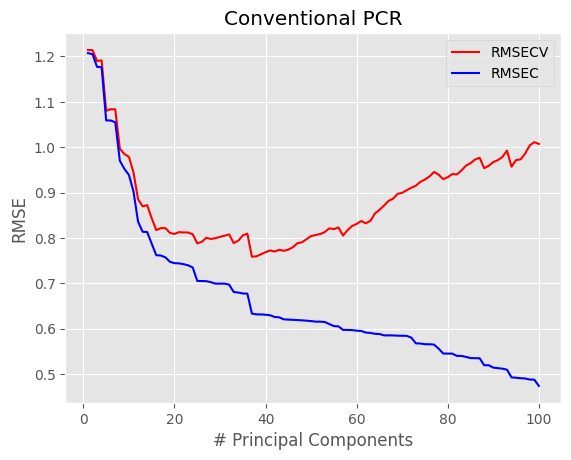

In [44]:
with plt.style.context(('ggplot')):
    plt.plot(pc, np.sqrt(rmsecv[:]), 'r', label = "RMSECV")
    plt.plot(pc, np.sqrt(rmsec[:]), 'b', label = "RMSEC")
    plt.xlabel("# Principal Components")
    plt.ylabel("RMSE")
    plt.title("Conventional PCR")
    plt.legend()
    plt.show()

When modelling we want to carefully select the parameters. In the case of PCR we can vary the number of principal components that we use in regression. We always aim for the model that predicts well on unseen data

In [45]:
pc = np.argmin(rmsecv)

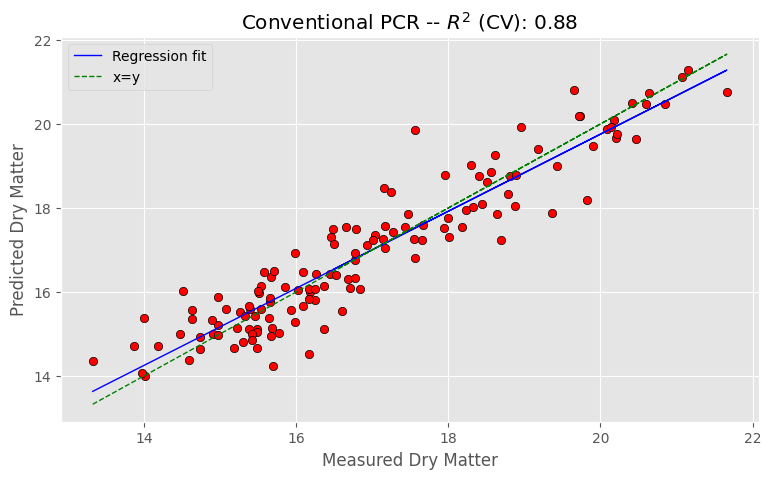

In [46]:
predicted, r2r, r2cv, mser, mscv = pcr(X_cal,y_cal, pc=pc)
# Regression plot
z = np.polyfit(y_cal, predicted, 1)
with plt.style.context(('ggplot')):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(y_cal, predicted, c='red', edgecolors='k')
    ax.plot(y_cal, z[1]+z[0]*y_cal, c='blue', linewidth=1, label = "Regression fit")
    ax.plot(y_cal, y_cal, color='green', linewidth=1, label="x=y", linestyle='--')
    plt.title('Conventional PCR -- $R^2$ (CV): {0:.2f}'.format(r2cv))
    plt.xlabel('Measured Dry Matter')
    plt.ylabel('Predicted Dry Matter')
    plt.legend()
    plt.show()

Let's also inspect cross-validated predictions and test set predictions

In [47]:
from sklearn.metrics import root_mean_squared_error

def plot_cv_vs_test(y_cal, y_cv, y_test, y_test_pred, plot_titles=["Cross-Validated Predictions", "Test Predictions"]):
    """
    Plot a comparison of cross-validated vs. test set predictions.

    Parameters
    ----------
    y_cal : array-like, shape (n_samples_cal,)
        True target values for the calibration (training) set.
    y_cv : array-like, shape (n_samples_cal,)
        Cross-validated predicted values for the calibration set.
    y_test : array-like, shape (n_samples_test,)
        True target values for the test set.
    y_test_pred : array-like, shape (n_samples_test,)
        Predicted values for the test set.
    plot_titles : list of str (2), optional
        Plot titles to use.
    """
    # Compute metrics
    r2_cv = r2_score(y_cal, y_cv)
    rmse_cv = root_mean_squared_error(y_cal, y_cv)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Prepare figure
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Combined axis limits
    all_actual = np.concatenate([y_cal, y_test])
    all_pred = np.concatenate([y_cv, y_test_pred])
    vmin = min(all_actual.min(), all_pred.min())*0.95
    vmax = max(all_actual.max(), all_pred.max())*1.05

    # Plot CV
    axs[0].scatter(y_cal, y_cv, alpha=0.6)
    axs[0].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[0].set_title(plot_titles[0])
    axs[0].set_xlabel('Actual')
    axs[0].set_ylabel('Predicted')
    axs[0].set_aspect('equal', 'box')
    axs[0].text(0.05, 0.95, f"R² = {r2_cv:.2f}\nRMSE = {rmse_cv:.2f}",
                transform=axs[0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Plot Test
    axs[1].scatter(y_test, y_test_pred, alpha=0.6, color='orange')
    axs[1].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[1].set_title(plot_titles[1])
    axs[1].set_xlabel('Actual')
    axs[1].set_ylabel('Predicted')
    axs[1].set_aspect('equal', 'box')
    axs[1].text(0.05, 0.95, f"R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}",
                transform=axs[1].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Set same limits
    for ax in axs:
        ax.set_xlim(vmin, vmax)
        ax.set_ylim(vmin, vmax)

    plt.tight_layout()
    plt.show()

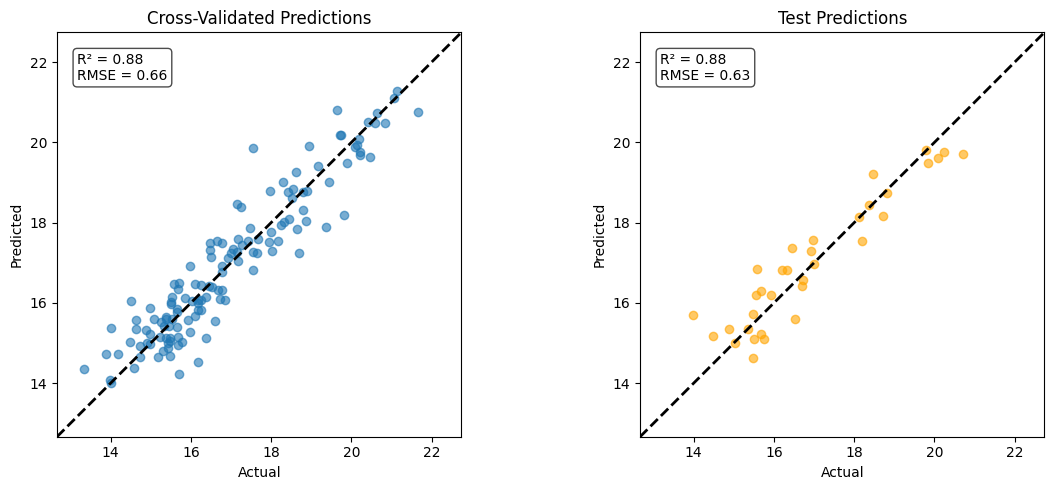

In [48]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_predict

pca = PCA()
standard_scaler_cal = StandardScaler()
Xstd = standard_scaler_cal.fit_transform(X_cal)
Xreg = pca.fit_transform(Xstd)[:,:pc]
# Cross-validation prediction on training set
y_cv = cross_val_predict(linear_model.LinearRegression(), Xreg, y_cal, cv=10)

X_test_std = standard_scaler_cal.transform(X_test)
X_test_reg = pca.transform(X_test_std)[:,:pc]

# Fit model on full calibration set
model = linear_model.LinearRegression()
model.fit(Xreg, y_cal)

# Predict on test set
y_test_pred = model.predict(X_test_reg)

plot_cv_vs_test(y_cal, y_cv, y_test, y_test_pred)

### Partial Least Squares Regression

In the analysis of Near-Infrared (NIR) spectroscopy data, Partial Least Squares Regression (PLSR) is a powerful technique for handling high-dimensional and collinear datasets. PLSR constructs latent variables that not only capture the variance in the predictor variables but also ensure maximum covariance with the response variables. This dual objective makes PLSR particularly effective for predictive modeling in scenarios where traditional regression techniques may struggle.

In [ ]:
# chemotools.regression.PLSRegression extends sklearn's PLSRegression with two extra
# attributes after fitting:
#   pls.explained_x_variance_ratio_  — variance in X explained per component
#   pls.explained_y_variance_ratio_  — variance in y explained per component

from chemotools.regression import PLSRegression as ChemoPLSRegression
from sklearn.model_selection import cross_val_predict

pls = ChemoPLSRegression(n_components=n_comp)

y_cv = cross_val_predict(pls, X_cal, y_cal, cv=10)
pls.fit(X_cal, y_cal)
y_test_pred = pls.predict(X_test)

print(f"Explained X variance (cumulative): {pls.explained_x_variance_ratio_.sum():.1%}")
print(f"Explained y variance (cumulative): {pls.explained_y_variance_ratio_.sum():.1%}")

plot_cv_vs_test(y_cal, y_cv, y_test, y_test_pred)

In [50]:
import joblib

joblib.dump(pls, f'{results_dir}/plsr_model.pkl') # let's save the model

['results/plsr_model.pkl']

## Model diagnostics

In Partial Least Squares (PLS) regression, selecting the right number of components is crucial to balance underfitting and overfitting. The bias–variance plot shows how training error and cross-validation error change as model complexity increases:

- When using too few components, the model is too simple to capture patterns in the data, resulting in high training and CV error — this is underfitting.

- As you increase the number of components, the model captures more variance in the data, reducing training error.

- Eventually, the model may begin to overfit, capturing noise in the training set. This causes CV error to increase even though training error continues to fall.

The optimal number of PLS components is where the CV error reaches its minimum. This is the point of best generalization to unseen data. If multiple component counts give similar (flat) CV error, prefer the simpler model (with fewer components).

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict

def optimise_pls_cv_test(X_train, y_train, X_test, y_test, n_comp):
    """
    Run PLS with multiple outputs, using cross-validation to compute MSE for each number of components.
    Also evaluate and plot test set performance.
    
    Parameters
    ----------
    X_train : array-like, shape (n_samples_train, n_features)
        Calibration (training) features.
    y_train : array-like, shape (n_samples_train, n_targets)
        Calibration (training) target(s).
    X_test : array-like, shape (n_samples_test, n_features)
        Test set features.
    y_test : array-like, shape (n_samples_test, n_targets)
        Test set target(s).
    n_comp : int
        Maximum number of PLS components to try.
    
    Returns
    -------
    n_comp: int of optimal number of PLS components
    """
    rmse_cv = []
    rmse_test = []
    rmse_train = []
    components = np.arange(1, n_comp + 1)

    for i in components:
        pls = PLSRegression(n_components=i)
        y_cv = cross_val_predict(pls, X_train, y_train, cv=10)
        rmse_cv.append(root_mean_squared_error(y_train, y_cv))
        pls = PLSRegression(n_components=i)
        pls.fit(X_train, y_train)
        y_train_pred = pls.predict(X_train)
        y_test_pred = pls.predict(X_test)
        rmse_train.append(root_mean_squared_error(y_train, y_train_pred))
        rmse_test.append(root_mean_squared_error(y_test, y_test_pred))
        sys.stdout.write(f"\r{i/n_comp*100:.1f}% completed")
        sys.stdout.flush()
    sys.stdout.write("\n")

    best_idx = int(np.argmin(rmse_cv))
    best_n = best_idx + 1
    print("Suggested number of components:", best_n)

    with plt.style.context("ggplot"):
        plt.figure(figsize=(8, 5))
        plt.plot(components, rmse_train, label='Training RMSE', marker='o', color='green')
        plt.plot(components, rmse_cv, label='CV RMSE', marker='o', color='red')
        plt.plot(components, rmse_test, marker='o', color='blue', label='Test RMSE')
        plt.xlabel('Number of PLS Components')
        plt.ylabel('Root Mean Squared Error')
        plt.title('Bias-Variance Trade-off in PLS')
        plt.legend()
        plt.grid(True)
        plt.show()
    return best_n

3.3% completed

100.0% completed
Suggested number of components: 11


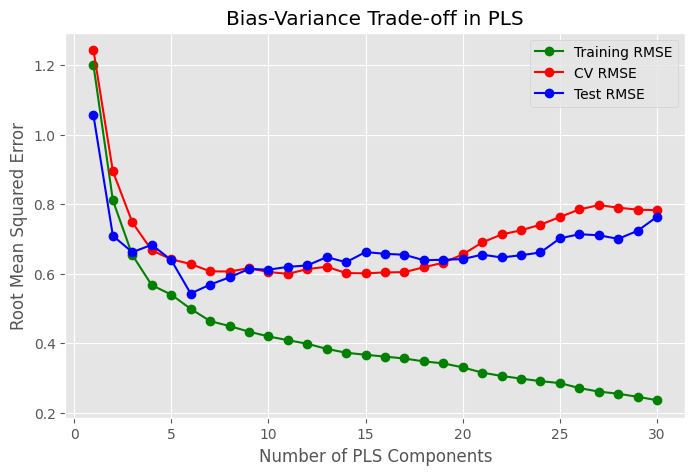

In [52]:
opt_n_comp = optimise_pls_cv_test(X_cal, y_cal, X_test, y_test, n_comp=30)

## Supervised outlier removal with PLS

While we're at it, let's look at another technique to address outliers is supervised, meaning the reference values are used to detect such outliers. To identify outliers, we can use methods such as residual analysis, leverage statistics, and Q residuals and T2 statistics. These techniques help pinpoint samples that deviate from the norm and may distort regression results.

The following Python code demonstrates how to detect outliers using PLS regression.

In [ ]:
from chemotools.outliers import HotellingT2, QResiduals

ncomp = opt_n_comp
pls = ChemoPLSRegression(n_components=ncomp).fit(X_cal, y_cal)

# --- Manual implementation (what's happening inside) ---
# T = pls.x_scores_
# P = pls.x_loadings_
# Err = X_cal - T @ P.T
# Q   = np.sum(Err**2, axis=1)
# Tsq = np.sum((T / np.std(T, axis=0))**2, axis=1)

# --- With chemotools ---
# HotellingT2: distance of each sample from the model centre in latent space.
# QResiduals : unexplained variance — how much of X the model misses.
t2_detector = HotellingT2(model=pls, confidence=0.95)
t2_detector.fit(X_cal)
Tsq = t2_detector.predict_residuals(X_cal)

q_detector = QResiduals(model=pls, confidence=0.95, method="percentile")
q_detector.fit(X_cal)
Q = q_detector.predict_residuals(X_cal)

In [ ]:
# Critical values come directly from the fitted detectors.
# No manual chi-square / empirical loop needed.
Tsq_conf = t2_detector.critical_value_
Q_conf   = q_detector.critical_value_

print(f"Hotelling T² critical value (95%): {Tsq_conf:.2f}")
print(f"Q residuals critical value (95th percentile): {Q_conf:.4f}")

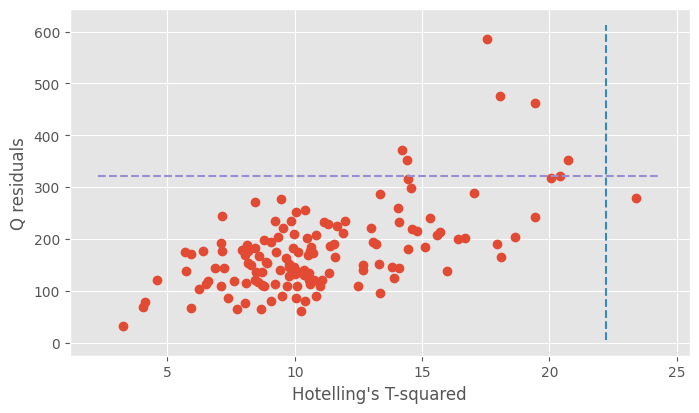

In [55]:
ax = plt.figure(figsize=(8,4.5))
with plt.style.context(('ggplot')):
    plt.plot(Tsq, Q, 'o')
 
    plt.plot([Tsq_conf,Tsq_conf],[plt.axis()[2],plt.axis()[3]],  '--')
    plt.plot([plt.axis()[0],plt.axis()[1]],[Q_conf,Q_conf],  '--')
    plt.xlabel("Hotelling's T-squared")
    plt.ylabel('Q residuals')
 
plt.show()

In [ ]:
# predict() returns a boolean array: True = outlier (exceeds critical value).
# Use predict_residuals() when you need the actual T² / Q values for plotting.
tsq_outliers = t2_detector.predict(X_cal)
q_outliers   = q_detector.predict(X_cal)
outliers     = tsq_outliers | q_outliers          # flagged by either detector

# RMS distance combines both statistics for a single ranking
rms_values = np.sqrt(Q**2 + Tsq**2)
outlier_indices_supervised = np.where(outliers)[0]
print("Supervised outlier indices:", outlier_indices_supervised)

In [57]:
outlier_indices_supervised

array([13, 27, 58, 72, 76, 83, 97])

In [58]:
# Remove those rows from input and output data
X_train = np.delete(X_cal, outlier_indices_supervised, axis=0)
Y_train = np.delete(y_cal, outlier_indices_supervised, axis=0)

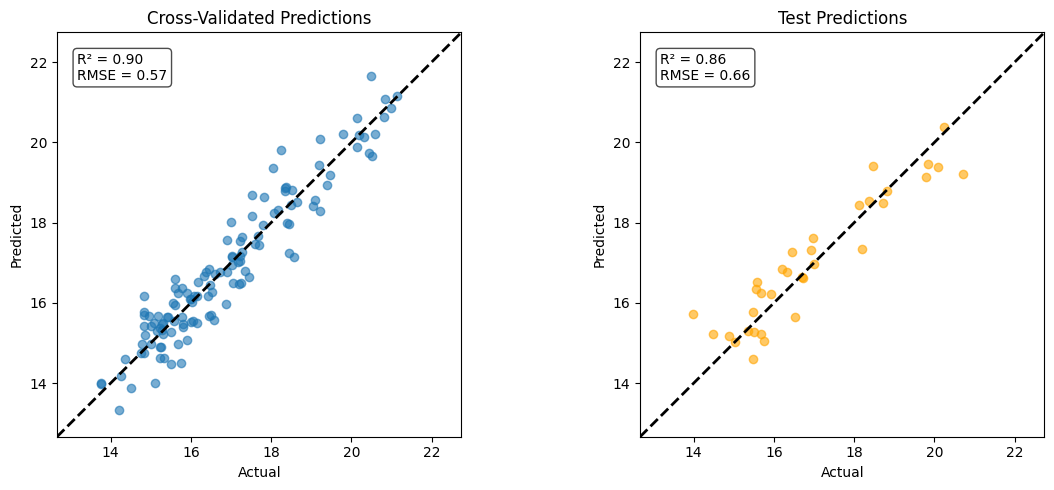

In [59]:
pls = PLSRegression(n_components=ncomp)

# Cross-validation prediction
y_cv = cross_val_predict(pls, X_train, Y_train, cv=10)

# Calibration prediction
pls.fit(X_train, Y_train)
y_test_pred = pls.predict(X_test)
plot_cv_vs_test(y_cv, Y_train, y_test, y_test_pred)

## Deep learning methods (simple convolution)

Deep learning offers a powerful approach to model complex relationships between spectral data and the properties of interest. Deep learning models with FC layers are essentially multi-layer perceptrons where each layer consists of neurons fully connected to all neurons in the previous layer. By utilizing fully connected (FC) layers, we can build neural network models capable of capturing intricate patterns within the data.

In [60]:
import tensorflow as tf
from tensorflow.keras import regularizers

model = tf.keras.Sequential([
tf.keras.layers.Dense(224, activation='relu'),
tf.keras.layers.Dense(16, activation='relu'),
tf.keras.layers.Dense(1, activation="linear")])

2025-11-10 14:15:40.984440: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 14:15:41.346131: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762780541.460455    5116 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762780541.497510    5116 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762780541.769322    5116 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_train, X_val, y_train, y_val = train_test_split(X_cal, y_cal,test_size=0.2,random_state=42)
 
scaler = MinMaxScaler()
scaler.fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_val = scaler.transform(X_val)
Xs_test = scaler.transform(X_test)

In [62]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss = "mse", 
              metrics =["accuracy"])
history = model.fit(Xs_train, y_train, epochs=500,
            validation_data=(Xs_val, y_val), 
            verbose=1)

Epoch 1/500


2025-11-10 14:15:47.079720: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.0000e+00 - loss: 276.8303 - val_accuracy: 0.0000e+00 - val_loss: 180.3988
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0000e+00 - loss: 182.8616 - val_accuracy: 0.0000e+00 - val_loss: 103.2582
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0000e+00 - loss: 103.1235 - val_accuracy: 0.0000e+00 - val_loss: 42.2707
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0000e+00 - loss: 41.0024 - val_accuracy: 0.0000e+00 - val_loss: 7.0760
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0000e+00 - loss: 8.2586 - val_accuracy: 0.0000e+00 - val_loss: 9.5220
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0000e+00 - loss: 10.1824 - val_accuracy: 0.0000e+00 - val_loss: 24.4929
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0000e+00 - loss: 18.6658 - val_accuracy: 0.0000e+00 - val_loss: 17.9879
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accura

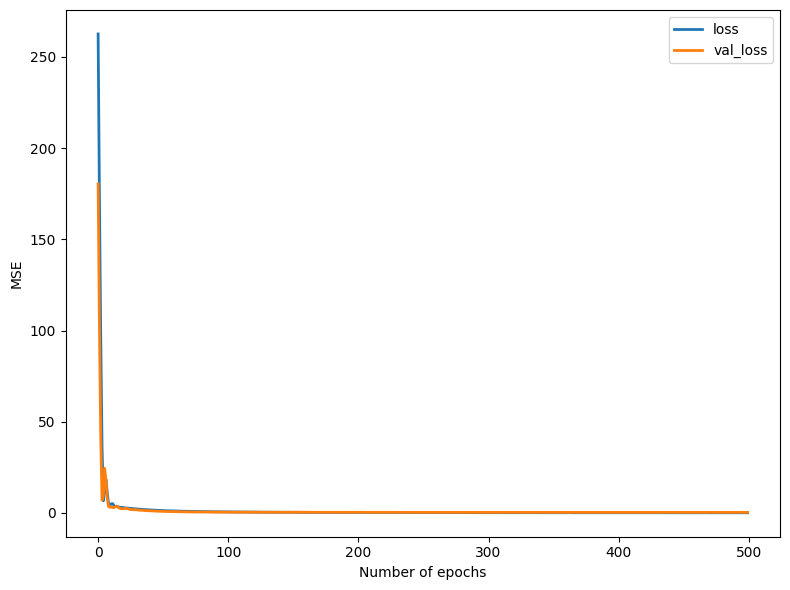

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(history.history['loss'], linewidth=2, label='loss')
ax.plot(history.history['val_loss'], linewidth=2, label='val_loss')
ax.set_xlabel('Number of epochs')
ax.set_ylabel('MSE')
plt.legend()

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


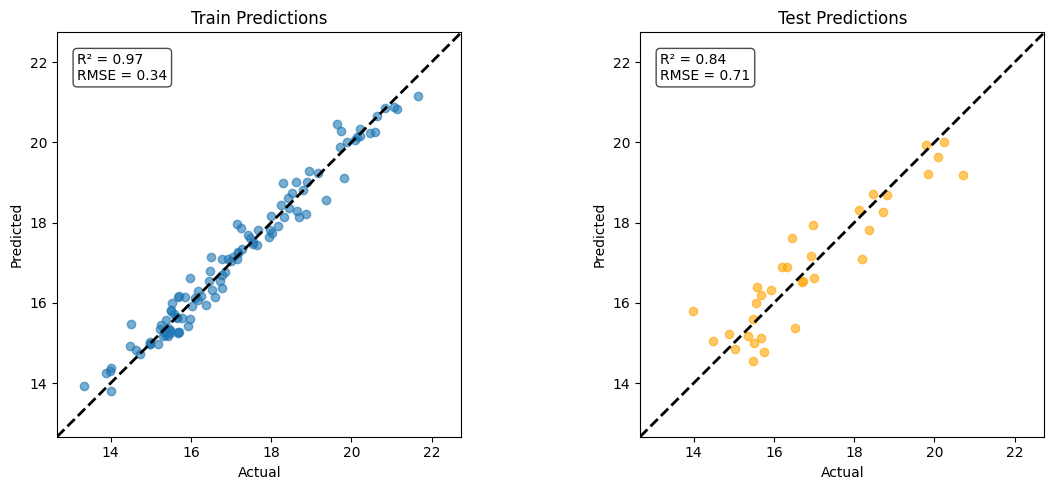

In [64]:
test_predictions = model.predict(Xs_test)
train_predictions = model.predict(Xs_train)
plot_cv_vs_test(y_train, train_predictions, y_test, test_predictions, plot_titles=["Train Predictions", "Test Predictions"] )
